#### **PRÁCTICA 3- PARTE 2: Análisis de Señales de EEG para Imaginería Motora**


**Estudiantes**

Luisa María Martínez Muelas

Carolina Taborda Vargas

In [101]:
#Importación de librerías necesarias para el proyecto

import numpy as np
import pandas as pd
import mne
from autoreject import AutoReject

Para el desarrollo de este análisis se seleccionaron los sujetos S001, S002, S016, S004, S028, S032, S040, S043,S062, S098 de la base de datos. De los 14 runs disponibles por sujeto, se utilizaron únicamente los runs R04, R08 y R12, que corresponden a las tres repeticiones de la Tarea 2: imaginería motora de mano izquierda o derecha. Dentro de estos runs, los eventos están etiquetados como T1 (imaginería de mano izquierda) y T2 (imaginería de mano derecha), siendo estas las dos clases de interés para el análisis comparativo. 

In [102]:
#Sujetos que vamos a analizar
subjects = ['001','002', '004', '016', '028', '032', '040', '043', '062', '098']  

raws = {}  

for subj in subjects:
    #Abrimos los runs de las tareas
    raw_r04 = mne.io.read_raw_eeglab(f'sub-{subj}_task-motion_run-4_eeg.set', preload=True)
    raw_r08 = mne.io.read_raw_eeglab(f'sub-{subj}_task-motion_run-8_eeg.set', preload=True)
    raw_r12 = mne.io.read_raw_eeglab(f'sub-{subj}_task-motion_run-12_eeg.set', preload=True)

    raw = mne.concatenate_raws([raw_r04, raw_r08, raw_r12])

    raws[subj] = raw

    print(raw)
    print(raw.info)

<RawEEGLAB | sub-001_task-motion_run-4_eeg.set, 64 x 60000 (375.0 s), ~29.4 MB, data loaded>
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5, Fc3, Fc1, Fcz, Fc2, Fc4, Fc6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: unspecified
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
>
<RawEEGLAB | sub-002_task-motion_run-4_eeg.set, 64 x 59040 (369.0 s), ~28.9 MB, data loaded>
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5, Fc3, Fc1, Fcz, Fc2, Fc4, Fc6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: unspecified
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
>
<RawEEGLAB | sub-004_task-motion_run-4_eeg.set, 64 x 59040 (369.0 s), ~28.9 MB, data loaded>
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5, Fc3, Fc1, Fcz, Fc2, Fc4, Fc6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_r

In [103]:
#Exploración de los canales que tenemos en el set de datos 
print(raw.ch_names)

['Fc5', 'Fc3', 'Fc1', 'Fcz', 'Fc2', 'Fc4', 'Fc6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'Cp5', 'Cp3', 'Cp1', 'Cpz', 'Cp2', 'Cp4', 'Cp6', 'Fp1', 'Fpz', 'Fp2', 'Af7', 'Af3', 'Afz', 'Af4', 'Af8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'Ft7', 'Ft8', 'T7', 'T8', 'T9', 'T10', 'Tp7', 'Tp8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'Po7', 'Po3', 'Poz', 'Po4', 'Po8', 'O1', 'Oz', 'O2', 'Iz']


Una vez seleccionados los runs correspondientes a la tarea de imaginería motora, se procedió a cargar las señales EEG utilizando la librería MNE de Python, mediante la función read_raw_eeglab(). Los tres runs fueron concatenados en un único objeto de señal continua, resultando en un registro de 64 canales con una frecuencia de muestreo de 160 Hz y una duración total de 375 segundos. 

#### **Discriminación entre grupos: mano izquierda y mano derecha**

In [104]:
# Extraer eventos del archivo
events, event_id = mne.events_from_annotations(raw)
print(event_id)  

{'TASK2T0': 1, 'TASK2T1': 2, 'TASK2T2': 3}


TASK2T1 = Imaginería mano izquierda 
TASK2T2 = Imaginería mano derecha 

Dado que la señal EEG fue registrada de forma continua durante toda la sesión experimental, es necesario segmentarla en fragmentos más pequeños denominados épocas, cada uno asociado a un evento específico de imaginería motora. Una época corresponde a un recorte temporal de la señal alrededor de cada marcador de evento, en este caso desde el inicio del estímulo hasta 4 segundos después, ventana que captura la respuesta cerebral completa asociada a cada tarea. Para este proceso se utilizó la función Epochs de la librería MNE, indicando únicamente los eventos de interés: TASK2T1 (imaginería mano izquierda) y TASK2T2 (imaginería mano derecha), descartando los períodos de reposo (TASK2T0).

In [105]:
for subj in subjects:
    
    raw = raws[subj]

    events, event_id = mne.events_from_annotations(raw)

    event_id_interes = {'Izquierda': 2, 'Derecha': 3}

    epochs = mne.Epochs(raw, events, event_id=event_id_interes,
                        tmin=0.0, tmax=4.0,
                        baseline=None,
                        preload=True)

    print(f"\nSujeto {subj}")
    print(epochs)

    epochs_izq = epochs['Izquierda']
    epochs_der = epochs['Derecha']

    print(f'Épocas mano izquierda: {len(epochs_izq)}')
    print(f'Épocas mano derecha: {len(epochs_der)}')


Sujeto 001
<Epochs | 45 events (all good), 0 – 4 s (baseline off), ~14.2 MB, data loaded,
 'Izquierda': 23
 'Derecha': 22>
Épocas mano izquierda: 23
Épocas mano derecha: 22

Sujeto 002
<Epochs | 45 events (all good), 0 – 4 s (baseline off), ~14.2 MB, data loaded,
 'Izquierda': 23
 'Derecha': 22>
Épocas mano izquierda: 23
Épocas mano derecha: 22

Sujeto 004
<Epochs | 45 events (all good), 0 – 4 s (baseline off), ~14.2 MB, data loaded,
 'Izquierda': 23
 'Derecha': 22>
Épocas mano izquierda: 23
Épocas mano derecha: 22

Sujeto 016
<Epochs | 45 events (all good), 0 – 4 s (baseline off), ~14.2 MB, data loaded,
 'Izquierda': 22
 'Derecha': 23>
Épocas mano izquierda: 22
Épocas mano derecha: 23

Sujeto 028
<Epochs | 45 events (all good), 0 – 4 s (baseline off), ~14.2 MB, data loaded,
 'Izquierda': 22
 'Derecha': 23>
Épocas mano izquierda: 22
Épocas mano derecha: 23

Sujeto 032
<Epochs | 45 events (all good), 0 – 4 s (baseline off), ~14.2 MB, data loaded,
 'Izquierda': 21
 'Derecha': 24>
Épocas

Se identificaron aproximadamente 45 eventos por sujeto, correspondientes a tareas de imaginería motora. Las épocas se distribuyeron en dos clases (mano izquierda y derecha), con una ligera variación en el número de ensayos por condición (22–23), lo cual es esperado en este tipo de registros experimentales. 

#### **1. Cálculo del RMS**


In [106]:
#FUNCIÓN PARA EL CÁLCULO DE RMS 

import numpy as np

def calcular_rms(epochs):
    # datos shape: (n_epocas, n_canales, n_tiempos)
    datos = epochs.get_data()
    
    # RMS por época y canal (sobre eje tiempo)
    rms_por_epoca = np.sqrt(np.mean(datos**2, axis=2)) 
    
    # Promedio sobre las épocas
    rms_promedio = np.mean(rms_por_epoca, axis=0) 
    
    return rms_promedio

rms_izq = calcular_rms(epochs_izq)
rms_der = calcular_rms(epochs_der)


In [107]:
for subj in subjects:

    raw = raws[subj]
    events, event_id = mne.events_from_annotations(raw)

    event_id_interes = {'Izquierda': 2, 'Derecha': 3}

    epochs = mne.Epochs(raw, events, event_id=event_id_interes,
                        tmin=0.0, tmax=4.0,
                        baseline=None,
                        preload=True)

    epochs_izq = epochs['Izquierda']
    epochs_der = epochs['Derecha']

    rms_izq = calcular_rms(epochs_izq)
    rms_der = calcular_rms(epochs_der)

    print(f"SUJETO {subj}")

    print(f"{'Canal':<6} {'Izquierda':>12} {'Derecha':>12}")
    print("-"*32)

    for i, c in enumerate(epochs.ch_names):
        print(f"{c:<6} {rms_izq[i]:>12.6f} {rms_der[i]:>12.6f}")

SUJETO 001
Canal     Izquierda      Derecha
--------------------------------
Fc5        0.000046     0.000061
Fc3        0.000047     0.000059
Fc1        0.000049     0.000060
Fcz        0.000052     0.000061
Fc2        0.000049     0.000055
Fc4        0.000043     0.000047
Fc6        0.000038     0.000042
C5         0.000047     0.000058
C3         0.000047     0.000055
C1         0.000049     0.000058
Cz         0.000052     0.000059
C2         0.000052     0.000056
C4         0.000042     0.000046
C6         0.000037     0.000040
Cp5        0.000045     0.000052
Cp3        0.000047     0.000054
Cp1        0.000049     0.000056
Cpz        0.000051     0.000057
Cp2        0.000048     0.000052
Cp4        0.000045     0.000049
Cp6        0.000039     0.000043
Fp1        0.000060     0.000088
Fpz        0.000052     0.000075
Fp2        0.000057     0.000077
Af7        0.000059     0.000084
Af3        0.000057     0.000082
Afz        0.000047     0.000062
Af4        0.000047     0.000058

#### **Construcción de la Base de Datos Poblacional**

In [108]:
import pandas as pd
import mne

lista_resultados = []

for subj in subjects:
    raw = raws[subj]
    events, _ = mne.events_from_annotations(raw)

    epochs = mne.Epochs(
        raw, events,
        event_id={'Izquierda': 2, 'Derecha': 3},
        tmin=0.0, tmax=4.0,
        baseline=None,
        preload=True
    )

    if 'Izquierda' not in epochs.event_id or 'Derecha' not in epochs.event_id:
        continue

    rms_izq = calcular_rms(epochs['Izquierda'])
    rms_der = calcular_rms(epochs['Derecha'])

    lista_resultados.append({
        'Sujeto': subj,
        'Condicion': 'Izquierda',
        **dict(zip(epochs.ch_names, rms_izq))
    })

    lista_resultados.append({
        'Sujeto': subj,
        'Condicion': 'Derecha',
        **dict(zip(epochs.ch_names, rms_der))
    })

df_final = pd.DataFrame(lista_resultados)

df_ancho = df_final.pivot_table(
    index=['Sujeto', 'Condicion'], 
    values=df_final.columns.drop(['Sujeto', 'Condicion'])
)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

display(df_ancho.style.format("{:.6f}").set_caption("Base de Datos Poblacional - RMS Promedio [cite: 18]"))

#### **3. Identificación de Canales Diferenciales mediante Análisis Estadístico**

Determinación de diferencias estadísticas significativas entre cada grupo de tareas (Izquierda vs. derecha) siguiendo el flujo de validación

**Prueba de normalidad: Shapiro Wilk**

In [109]:
import pandas as pd
import mne
mne.set_log_level('ERROR')

lista_resultados = []

for subj in subjects:
    raw = raws[subj]
    events, _ = mne.events_from_annotations(raw)

    epochs = mne.Epochs(
        raw, events,
        event_id={'Izquierda': 2, 'Derecha': 3},
        tmin=0.0, tmax=4.0,
        baseline=None,
        preload=True
    )

    if 'Izquierda' not in epochs.event_id or 'Derecha' not in epochs.event_id:
        continue

    rms_izq = calcular_rms(epochs['Izquierda'])
    rms_der = calcular_rms(epochs['Derecha'])

    lista_resultados.append({
        'Sujeto': subj,
        'Condicion': 'Izquierda',
        **dict(zip(epochs.ch_names, rms_izq))
    })

    lista_resultados.append({
        'Sujeto': subj,
        'Condicion': 'Derecha',
        **dict(zip(epochs.ch_names, rms_der))
    })

df_final = pd.DataFrame(lista_resultados)

df_ancho = df_final.pivot_table(
    index=['Sujeto', 'Condicion'], 
    values=df_final.columns.drop(['Sujeto', 'Condicion'])
)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

display(df_ancho.style.format("{:.6f}").set_caption("Base de Datos Poblacional - RMS Promedio [cite: 18]"))

In [ ]:
from scipy.stats import shapiro
import pandas as pd

resultados_norm = []

canales = df_final.columns.drop(['Sujeto', 'Condicion']).tolist()

for canal in canales:
    
    izq = df_final[df_final['Condicion'] == 'Izquierda'][canal].dropna()
    der = df_final[df_final['Condicion'] == 'Derecha'][canal].dropna()

    _, p_izq = shapiro(izq)
    _, p_der = shapiro(der)

    resultados_norm.append({
        'Canal': canal,
        'p_Izquierda': round(p_izq, 5),
        'Normal_Izquierda': p_izq > 0.05,
        'p_Derecha': round(p_der, 5),
        'Normal_Derecha': p_der > 0.05,
        'Normalidad_Canal': (p_izq > 0.05 and p_der > 0.05)
    })

df_norm = pd.DataFrame(resultados_norm)

display(df_norm)

n_normales = df_norm['Normalidad_Canal'].sum()
n_no_normales = len(df_norm) - n_normales

print("\n=== RESUMEN ===")
print(f"Canales normales: {n_normales}")
print(f"Canales NO normales: {n_no_normales}")

,Canal,p_Izquierda,Normal_Izquierda,p_Derecha,Normal_Derecha,Normalidad_Canal
0,Fc5,0.06498,True,0.14722,True,True
1,Fc3,0.05566,True,0.16390,True,True
2,Fc1,0.10238,True,0.61911,True,True
3,Fcz,0.04908,False,0.06034,True,False
4,Fc2,0.04334,False,0.14890,True,False
5,Fc4,0.05708,True,0.08350,True,True
6,Fc6,0.05488,True,0.12294,True,True
7,C5,0.04280,False,0.16768,True,False
8,C3,0.03639,False,0.19655,True,False
9,C1,0.02373,False,0.10615,True,False



=== RESUMEN ===
Canales normales: 26
Canales NO normales: 38


Al evaluar la distribución de la potencia RMS mediante la prueba de Shapiro-Wilk, se observó un comportamiento heterogéneo entre los canales analizados. Mientras que electrodos como Af3, C4 y C6 mostraron una distribución normal en ambas condiciones (Izquierda y Derecha), otros canales presentaron normalidad solo en una de las dos tareas motoras o no cumplieron el supuesto en ninguna de ellas. 

En particular, se observa que en varios canales la condición Derecha tiende a cumplir el supuesto de normalidad, mientras que la condición Izquierda no lo hace, como ocurre en canales centrales como C1, C3 y Cz.

Esta inconsistencia en la distribución sugiere que la activación cortical durante la imaginería motora no es uniforme a través de todos los sujetos, posiblemente debido a la variabilidad en la ejecución de la tarea **[1]**. En consecuencia, para aquellos canales donde al menos una de las condiciones no cumplió con el supuesto de normalidad (como se observa en C1, C3 o Cz), se optará por el uso de pruebas no paramétricas. 

**Prueba de homocedasticidad**

Análisis con prueba de levene para verificar si las varianzas entre los grupos son iguales

In [111]:
from scipy.stats import levene
import pandas as pd

resultados_levene = []

canales = df_ancho.columns.tolist()

for canal in canales:

    izq = df_ancho.xs('Izquierda', level='Condicion')[canal].dropna()
    der = df_ancho.xs('Derecha', level='Condicion')[canal].dropna()

    stat, p_val = levene(izq, der)

    resultados_levene.append({
        'Canal': canal,
        'p_Levene': round(p_val, 5),
        'Homocedastico': "SI" if p_val > 0.05 else "NO"
    })

df_levene = pd.DataFrame(resultados_levene)

df_levene_wide = df_levene.set_index('Canal').T

pd.set_option('display.max_columns', None)
display(df_levene_wide)

Canal,Af3,Af4,Af7,Af8,Afz,C1,C2,C3,C4,C5,C6,Cp1,Cp2,Cp3,Cp4,Cp5,Cp6,Cpz,Cz,F1,F2,F3,F4,F5,F6,F7,F8,Fc1,Fc2,Fc3,Fc4,Fc5,Fc6,Fcz,Fp1,Fp2,Fpz,Ft7,Ft8,Fz,Iz,O1,O2,Oz,P1,P2,P3,P4,P5,P6,P7,P8,Po3,Po4,Po7,Po8,Poz,Pz,T10,T7,T8,T9,Tp7,Tp8
p_Levene,0.91441,0.94161,0.88709,0.90636,0.99386,0.81723,0.72522,0.74703,0.73028,0.75987,0.63658,0.72977,0.7989,0.80089,0.69328,0.70609,0.65384,0.804,0.78314,0.85621,0.83752,0.76397,0.91552,0.68924,0.98261,0.5787,0.9911,0.7158,0.8204,0.82167,0.73993,0.87328,0.73615,0.85621,0.95254,0.93591,0.92912,0.63584,0.81091,0.85899,0.63219,0.62637,0.59012,0.6255,0.74817,0.79679,0.81975,0.7419,0.71994,0.7017,0.91612,0.66253,0.6161,0.5978,0.6456,0.56169,0.77467,0.74619,0.58233,0.65065,0.66707,0.82068,0.98326,0.7522
Homocedastico,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI


Luego de realizar la prueba de Levene para análisis de homocedasticidad, todos los canales presentan varianzas iguales entre grupos, es decir, no hay diferencias estadísticas en la varianza de los valores RMS entre los grupos de la imaginería de mano izquierda y derecha

#### **Pruebas de hipótesis**

**Prueba U de Mann-Whitney**

Tras la verificación de los supuestos estadísticos, se procedió a realizar la comparación de los grupos (Mano Izquierda vs. Mano Derecha) para identificar diferencias significativas en la potencia de la señal (RMS). Para aquellos canales donde la distribución de los datos de los 10 sujetos no presentó un comportamiento normal según la prueba de Shapiro-Wilk, se empleará la Prueba U de Mann-Whitney. Esta técnica no paramétrica permite comparar las medianas de ambos grupos sin asumir una distribución específica, garantizando la validez de los resultados en canales con distribuciones sesgadas o presencia de valores atípicos.

In [112]:
from scipy.stats import mannwhitneyu

resultados_mw = []

n_canales_no_normales = len(canales_no_normales)

if n_canales_no_normales == 0:
    print("Todos los canales cumplen normalidad")
else:
    print(f"\nSe aplicará Mann-Whitney a {n_canales_no_normales} canales que NO cumplen normalidad.\n")

    for canal in canales_no_normales:

        izq = df_final[df_final['Condicion'] == 'Izquierda'][canal].dropna()
        der = df_final[df_final['Condicion'] == 'Derecha'][canal].dropna()

        stat, p_val = mannwhitneyu(izq, der, alternative='two-sided')

        resultados_mw.append({
            'Canal': canal,
            'U': stat,
            'p_MW': p_val,
            'Significativo': p_val < 0.05
        })

    df_mw = pd.DataFrame(resultados_mw)

    display(df_mw.style.format({'p_MW': '{:.5f}'}))

    no_sig = df_mw[df_mw['Significativo'] == False]

    if len(no_sig) == n_canales_no_normales:
        p_min = df_mw['p_MW'].min()
        p_max = df_mw['p_MW'].max()

        canal_min = df_mw.loc[df_mw['p_MW'].idxmin(), 'Canal']
        canal_max = df_mw.loc[df_mw['p_MW'].idxmax(), 'Canal']



Se aplicará Mann-Whitney a 38 canales que NO cumplen normalidad.



,Canal,U,p_MW,Significativo
0,Fcz,51.000000,0.96985,False
1,Fc2,52.000000,0.90972,False
2,C5,51.000000,0.96985,False
3,C3,49.000000,0.96985,False
4,C1,51.000000,0.96985,False
5,Cz,50.000000,1.00000,False
6,C2,49.000000,0.96985,False
7,Cp3,48.000000,0.90972,False
8,Cp1,51.000000,0.96985,False
9,Cp2,51.000000,0.96985,False


Tras la aplicación de la prueba U de Mann-Whitney en los 38 canales que no cumplieron el supuesto de normalidad, no se encontraron diferencias estadísticamente significativas entre las tareas de imaginería motora de mano izquierda y derecha (p > 0.05)

Los p-valores obtenidos, que oscilan entre 0.73373 (canal Tp8) y 1.0 (en canales como Cz, Fp1 y P1), indican que no se evidencian diferencias en la distribución de la potencia RMS entre ambos grupos en estos canales.

**Prueba t de student**

Para los canales que mostraron una distribución normal en los valores RMS según la prueba de Shapiro-Wilk, se procedió a realizar la comparación de medias mediante la Prueba t de Student para muestras independientes. Dado que la prueba de Levene confirmó previamente la homogeneidad de varianzas en todos los registros (p > 0.05), se empleó el estadístico asumiendo varianzas iguales. 

In [115]:
from scipy.stats import ttest_ind
import pandas as pd

# Canales que cumplen normalidad en ambas condiciones
canales_normales = df_norm[
    (df_norm['Normal_Izquierda'] == True) & 
    (df_norm['Normal_Derecha'] == True)
]['Canal'].tolist()

resultados_t = []

if not canales_normales:
    print("No se encontraron canales normales en ambas condiciones.")
else:
    for canal in canales_normales:

        izq = df_final[df_final['Condicion'] == 'Izquierda'][canal].dropna()
        der = df_final[df_final['Condicion'] == 'Derecha'][canal].dropna()

        stat, p_val = ttest_ind(izq, der, equal_var=True)

        resultados_t.append({
            'Canal': canal,
            'Estadístico t': stat,
            'p-valor (t)': p_val,
            'Significativo': p_val < 0.05
        })

    df_resultados_t = pd.DataFrame(resultados_t)

    print(f"Se aplicó t-test a {len(canales_normales)} canales normales:\n")

    display(df_resultados_t.style.format({
        'p-valor (t)': '{:.5f}',
        'Estadístico t': '{:.3f}'
    }))

Se aplicó t-test a 26 canales normales:



,Canal,Estadístico t,p-valor (t),Significativo
0,Fc5,0.186,0.85475,False
1,Fc3,0.174,0.86377,False
2,Fc1,0.140,0.89023,False
3,Fc4,0.252,0.80394,False
4,Fc6,0.248,0.80724,False
5,C4,0.331,0.74451,False
6,C6,0.379,0.70884,False
7,Cp5,0.189,0.85195,False
8,Cpz,0.227,0.82269,False
9,Cp4,0.287,0.77776,False


Luego de realizar la prueba t de student para los 26 canales identificados con los requisitos estadísticos, no se hallaron diferencias estadísticamente significativas (p > 0.05) en la potencia RMS entre las condiciones de imaginería motora izquierda y derecha para ninguno de estos electrodos. Los p-valores se mantuvieron en rangos altos, destacando canales como Af3 (p = 0.99682) y Fp2 (p = 0.95409), donde las medias de ambos grupos son prácticamente idénticas.Incluso en canales de interés motor como C4 (p = 0.74451), el estadístico 0.331 indica una diferencia de medias muy débil que no alcanza el umbral de significancia. Este hallazgo sugiere que, para este conjunto de datos, la variabilidad entre sujetos o el nivel de activación durante la tarea no permite una discriminación robusta basada únicamente en el valor RMS medio.

**Localización de canales diferenciales para ver su potencial para BCI**

In [ ]:
#PARA VER LOS CANALES QUE PUEDEN SER USADOS PARA BCI Y QUE PRESENTAN INFORMACIÓN DIFERENCIAL, VAMOS A LOCALIZAR SEGÚN LOS RESULTADOS DE LAS PRUEBAS ANTERIORES
#ESTO LO REALIZAMOS CON EL FIN DE QUE ENTRE TANTOS DATOS, PODAMOS COMPARAR FÁCILMENTE Y LLEGAR A UN RESULTADO ÓPTIMO

#Canal y p-valor de U de Mann
res_mw = df_resultados_mw[['Canal', 'p-valor (MW)']].rename(columns={'p-valor (MW)': 'p-valor'})

# Canal y p-valor de la prueba t-Student
res_t = df_resultados_t[['Canal', 'p-valor (t)']].rename(columns={'p-valor (t)': 'p-valor'})

# Concatenamos ambos resultados
df_final_stats = pd.concat([res_mw, res_t], ignore_index=True)

# Verificamos que se cumpla la concidión p-valor < 0.05
canales_clave = df_final_stats[df_final_stats['p-valor'] < 0.05]

print("IDENTIFICACIÓN DE CANALES CLAVE PARA BCI")
if canales_clave.empty:
    print("\nNo se encontraron canales con diferencias significativas (p < 0.05).")

    display(df_final_stats.sort_values('p-valor').head(10))
else:
    print(f"\nSe han localizado {len(canales_clave)} canales diferenciales:")
    display(canales_clave.sort_values('p-valor'))

IDENTIFICACIÓN DE CANALES CLAVE PARA BCI

No se encontraron canales con diferencias significativas (p < 0.05).


,Canal,p-valor
51,F7,0.649635
58,Ft7,0.667097
62,Po4,0.702457
42,C6,0.708842
45,Cp6,0.720601
61,P5,0.731876
37,Tp8,0.733730
63,T8,0.741726
41,C4,0.744506
43,Cp4,0.777756


#### **Ejemplo de visualización esperada**

C:\Users\carol\AppData\Local\Temp\ipykernel_3112\1542111559.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot([data_izq, data_der],


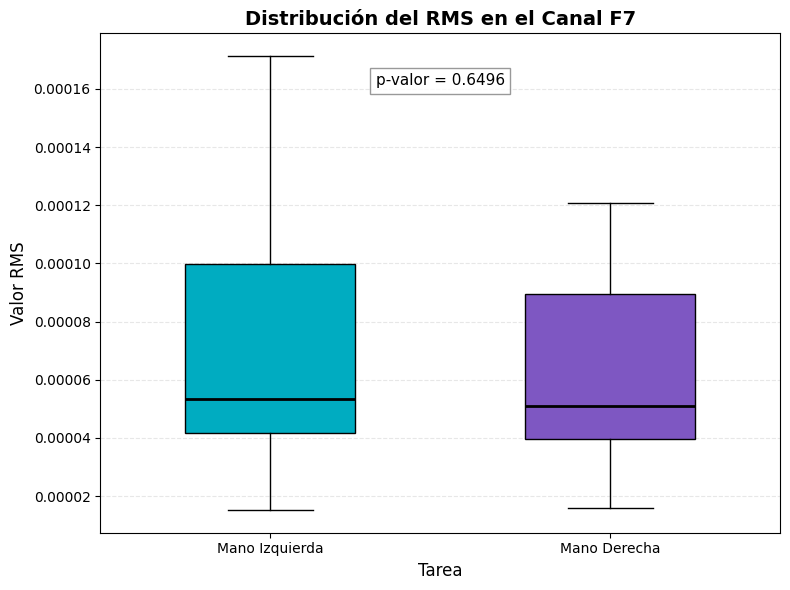

In [ ]:
import matplotlib.pyplot as plt

# Configuración del canal
canal_top = 'F7'
p_val_top = 0.649635

data_izq = df_ancho[('Izquierda', canal_top)].dropna()
data_der = df_ancho[('Derecha', canal_top)].dropna()

#Gráfica
plt.figure(figsize=(8, 6))
bp = plt.boxplot([data_izq, data_der], 
                labels=['Mano Izquierda', 'Mano Derecha'],
                patch_artist=True, 
                widths=0.5)
                
colors = ['#00ACC1', '#7E57C2']
for i, box in enumerate(bp['boxes']):
    box.set_facecolor(colors[i])
    box.set_edgecolor('black')

for median in bp['medians']:
    median.set(color='black', linewidth=2)

plt.title(f'Distribución del RMS en el Canal {canal_top}', fontsize=14, fontweight='bold')
plt.ylabel('Valor RMS', fontsize=12)
plt.xlabel('Tarea', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.text(1.5, plt.gca().get_ylim()[1] * 0.9, f'p-valor = {p_val_top:.4f}', 
        horizontalalignment='center', fontsize=11, 
        bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8))

plt.tight_layout()
plt.show()

El canal F7 fue seleccionado para la visualización por presentar el menor p-valor obtenido entre los 64 canales analizados (p = 0.6496), siendo así el de mayor significancia relativa, aunque sin alcanzar el umbral de significancia estadística (p < 0.05). El boxplot muestra que las distribuciones del RMS para Mano Izquierda y Mano Derecha se encuentran ampliamente solapadas, lo cual es consistente con el alto p-valor obtenido. Aunque la caja de Mano Izquierda presenta una mayor dispersión y valores más altos en su bigote superior, las medianas de ambos grupos son muy similares, lo que indica que no existe una diferencia estadísticamente significativa entre las dos condiciones en este canal. Este resultado sugiere que la amplitud de la señal EEG medida mediante RMS no es suficiente por sí sola para diferenciar las dos intenciones motoras con la muestra poblacional disponible, lo cual limita su utilidad directa para el control de una interfaz cerebro-computadora (BCI).

#### **Inclusión del canal C4**

Complementariamente, se incluye el análisis visual del canal C4, el cual se localiza sobre la corteza motora primaria del hemisferio derecho. En el diseño de interfaces cerebro-computadora basadas en imaginería motora, C4 es considerado un punto de interés fisiológico crítico, ya que se espera que presente una desincronización de ritmo mu durante la imaginación del movimiento de la mano contralateral (izquierda). A pesar de que en este estudio el valor RMS no alcanzó significancia estadística (p = 0.7445), su visualización es indispensable para contrastar los modelos teóricos de activación cortical con los datos experimentales obtenidos, permitiendo evaluar si la falta de discriminación se debe a la potencia global de la señal o a la necesidad de un filtrado de frecuencia más específico **[2]**.

C:\Users\carol\AppData\Local\Temp\ipykernel_3112\3080103548.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot([data_izq, data_der],


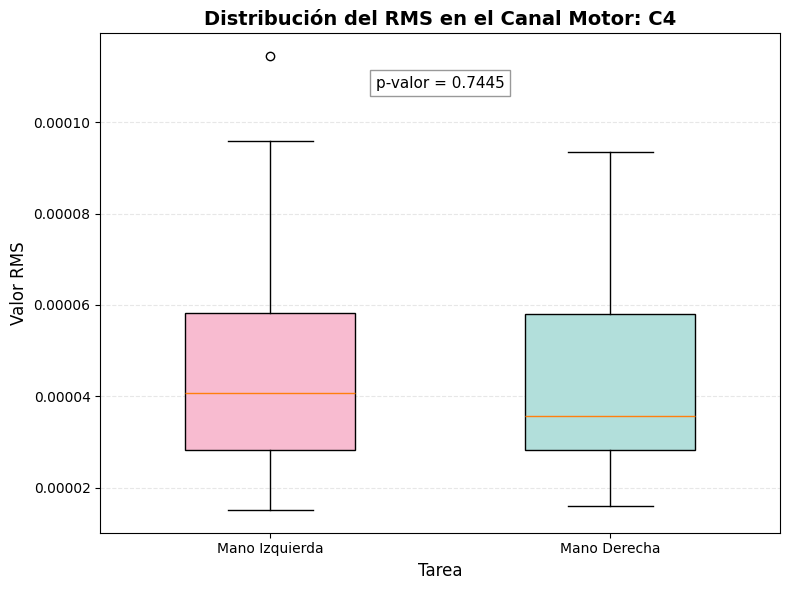

In [ ]:
import matplotlib.pyplot as plt

# Canal a graficar
canal_motor = 'C4'
p_val_c4 = 0.7445  

data_izq = df_ancho[('Izquierda', canal_motor)].dropna()
data_der = df_ancho[('Derecha', canal_motor)].dropna()

# Gráfica
plt.figure(figsize=(8, 6))
bp = plt.boxplot([data_izq, data_der], 
                labels=['Mano Izquierda', 'Mano Derecha'],
                patch_artist=True, 
                widths=0.5)

colors = ['#F8BBD0', '#B2DFDB']
for i, box in enumerate(bp['boxes']):
    box.set_facecolor(colors[i])

plt.title(f'Distribución del RMS en el Canal Motor: {canal_motor}', fontsize=14, fontweight='bold')
plt.ylabel('Valor RMS', fontsize=12)
plt.xlabel('Tarea', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.text(1.5, plt.gca().get_ylim()[1] * 0.9, f'p-valor = {p_val_c4:.4f}', 
        horizontalalignment='center', fontsize=11, 
        bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8))

plt.tight_layout()
plt.show()

El diagrama muestra que las cajas de ambas condiciones son casi idénticas en tamaño y posición, lo que justifica un p-valor alto de 0.7445. Las medianas (las líneas naranjas dentro de las cajas) están muy cerca una de la otra, lo que indica que el nivel de energía de la señal es prácticamente el mismo sin importar qué mano se imagine. Se observa un dato atípico (el círculo pequeño arriba) en la mano izquierda, pero no es suficiente para cambiar el resultado general. En conclusión, el canal C4 no muestra cambios claros en su valor RMS para distinguir las tareas, sugiriendo que la actividad motora en este punto es muy similar para ambas manos en este experimento.

Este hallazgo puede complementarse desde una perspectiva neurofisiológica. Yu et al. (2022) y Yin et al. (2016) postulan que la diferenciación en los canales de la corteza motora depende de la modulación específica de los ritmos Mu y Beta. La ausencia de significancia estadística en C4 sugiere que el valor RMS, al ser una medida de energía global, podría estar enmascarando los cambios sutiles de la Desincronización Relacionada con Eventos (ERD) que ocurren en bandas de frecuencia estrechas. Asimismo, según Wolpaw (2012), este fenómeno es común en sujetos sin entrenamiento previo (denominado BCI Illiteracy), quienes no logran generar una activación cortical lo suficientemente robusta o lateralizada para que métricas como el RMS logren capturar diferencias significativas entre la imaginería motora de la mano izquierda y la derecha.

#### **Referencias**

[1] Jorajuria, T., et al. (2026). A Neurophysiological Stratification Framework for Intermediate Motor Imagery-BCI Users Based on Independent Event-Related Brain Dynamics. PMC PubMed Central. Disponible en: https://pubmed.ncbi.nlm.nih.gov/41750203/

[2] Wolpaw, J. R., & Wolpaw, E. W. (2012). Brain-Computer Interfaces: Principles and Practice. Oxford University Press. Disponible en: https://www.ece.uprm.edu/~manian/BCI%20principles%20and%20practice.pdf

[3] Yu, H., Ba, S., Guo, Y., Guo, L., & Xu, G. (2022). Effects of Motor Imagery Tasks on Brain Functional Networks Based on EEG Mu/Beta Rhythm. Brain Sciences, 12(2), 194. Disponible en: https://doi.org/10.3390/brainsci12020194

[4] Yin, S., Liu, Y., & Ding, M. (2016). Amplitude of Sensorimotor Mu Rhythm is Correlated with BOLD from Multiple Brain Regions: A Simultaneous EEG-fMRI Study. Frontiers in Human Neuroscience, 10(364). Disponible en: https://doi.org/10.3389/fnhum.2016.00364
